# Imports and Data Cleaning

In [40]:
import ipywidgets as widgets
import io
import tabula
import pandas as pd
import numpy as np
import random
import math
import plotly.graph_objects as go
from IPython.display import display, clear_output
from PIL import Image
from IPython.display import Image as IPyImage

# Reads PDF and converts it to CSV file
tabula.convert_into("sherwin_colors.pdf", "sherwin_colors.csv", output_format="csv", pages="all", stream=True)
# Reads CSV file and skips rows that cause errors in data frame
df = pd.read_csv("sherwin_colors.csv", skiprows=[95,96,97,99,100,101,106,107,108,119,120,121])
# Renames columns in the data frame
df.columns = ["Num", "Name", "Loc", "Red", "Green", "Blue", "Hex", "Color"]

# Creates new rows that were previous skipped due to errors in the PDF file
new_rows = [
    {"Num": "SW2807", "Name": "Rookwood Medium Brown", "Loc": None, "Red": 110, "Green": 82, "Blue": 65, "Hex": "6E5241", "Color": None},
    {"Num": "SW2809", "Name": "Rookwood Shutter Green", "Loc": None, "Red": 48, "Green": 59, "Blue": 57, "Hex": "303B39", "Color": None},
    {"Num": "SW2814", "Name": "Rookwood Antique Gold", "Loc": None, "Red": 165, "Green": 130, "Blue": 88, "Hex": "A58258", "Color": None},
    {"Num": "SW2826", "Name": "Colonial Revival Green Stone", "Loc": None, "Red": 163, "Green": 155, "Blue": 126, "Hex": "A39B7E", "Color": None}
]

# Adds the new rows to the data frame
df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

# Creates a new column in the data frame that contains an image of the color based on the RGB values
for i in range(len(df)):
    df.loc[i, "Color"] = Image.new('RGB', (100, 100), color=(df["Red"][i], df["Green"][i], df["Blue"][i]))
# Displays the first 5 rows of the data frame
df.head()

,Num,Name,Loc,Red,Green,Blue,Hex,Color
0,SW0001,Mulberry Silk,NaN,148,118,108,94766C,<PIL.Image.Image image mode=RGB size=100x100 a...
1,SW0002,Chelsea Mauve,NaN,190,172,159,BEAC9F,<PIL.Image.Image image mode=RGB size=100x100 a...
2,SW0003,Cabbage Rose,NaN,197,159,145,C59F91,<PIL.Image.Image image mode=RGB size=100x100 a...
3,SW0004,Rose Brocade,NaN,153,108,110,996C6E,<PIL.Image.Image image mode=RGB size=100x100 a...
4,SW0005,Deepest Mauve,NaN,109,89,90,6D595A,<PIL.Image.Image image mode=RGB size=100x100 a...


# Random Target Color

Bittersweet Stem


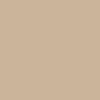

In [41]:
# Sets x to be a random interger between 0 and the length of the data frame
x = random.randint(0, len(df))

# Sets target to be the color name at index x in the data frame
target = df["Color"][x]
# Sets target_rgb to be the RGB values at index x in the data frame
target_rgb = (int(df["Red"][x]), int(df["Green"][x]), int(df["Blue"][x]))

# Prints the color name at index x in the data frame
print(df["Name"][x])
# Displays the color image at index x in the data frame
display(target)

# Manual Implementation 1

In [42]:
# Initializes the color dictionary with default RGB values of 127 for each channel (Grey)
color = {'R': 127, 'G': 127, 'B': 127}

# Creates output widgets for displaying the target color, current color, and their RGB values
color_out = widgets.Output()
target_out = widgets.Output()
rgb_out = widgets.Output()
target_rgb_out = widgets.Output()

# Displays the target color image in the target_out widget
with target_out:
    # Creates memory buffer to hold the image data
    img_byte_arr = io.BytesIO()
    # Saves the target image to the memory buffer in PNG format
    target.save(img_byte_arr, format='PNG')
    # Displays the image from the memory buffer using IPyImage
    display(IPyImage(img_byte_arr.getvalue()))

# Function to display the current color and its RGB values
def show_color():
    # Displays the current color image in the color_out widget
    with color_out:
        # Clears the previous output in the widget to avoid stacking images
        clear_output(wait=True)
        # Creates a new image with the current RGB values
        img = Image.new('RGB', (100, 100), (color['R'], color['G'], color['B']))
        # Creates a memory buffer to hold the image data known as output
        with io.BytesIO() as output:
            # Saves the current color image to the memory buffer in PNG format
            img.save(output, format="PNG")
            # Retrieves the image data from the memory buffer
            data = output.getvalue()
        # Displays the current color image using IPyImage
        display(IPyImage(data))

    # Displays the current RGB values in the rgb_out widget
    with rgb_out:
        # Clears the previous output in the widget to avoid stacking text
        clear_output(wait=True)
        # Prints the current RGB values in a formatted string
        print(f"RGB: ({color['R']}, {color['G']}, {color['B']})")

# Function to display the target RGB values in the target_rgb_out widget
def check_color():
    # Uses the target_rgb_out widget to display the target RGB values
    with target_rgb_out:
        # Clears the previous output in the widget to avoid stacking text
        clear_output(wait=True)
        # Prints the target RGB values in a formatted string
        print(f"Target RGB: {target_rgb}")

# Function to calculate how much to adjust the color based on the current value of the color channel
def color_quant(value):
    dec = len(str((value+1)/256))-3
    quant = 64/(2**dec)
    quant = math.ceil(quant)
    return quant

# Function to handle button clicks and adjust the color accordingly
def handle_click(option):
    # Adjusts the color based on the button clicked by the user
    if option == "More Red":
        color['R'] = min(color['R'] + color_quant(color['R']), 255)
    elif option == "Less Red":
        color['R'] = max(color['R'] - color_quant(color['R']), 0)
    elif option == "More Green":
        color['G'] = min(color['G'] + color_quant(color['G']), 255)
    elif option == "Less Green":
        color['G'] = max(color['G'] - color_quant(color['G']), 0)
    elif option == "More Blue":
        color['B'] = min(color['B'] + color_quant(color['B']), 255)
    elif option == "Less Blue":
        color['B'] = max(color['B'] - color_quant(color['B']), 0)
    # Checks the current color against the target color by displaying the target RGB values
    elif option == "Check Color":
        check_color()
    # Updates the display of the current color and its RGB values after any adjustment
    show_color()

# Creates list of names for the buttons to be displayed in the user interface
button_labels = ["More Red", "Less Red", "More Green", "Less Green", "More Blue", "Less Blue", "Check Color"]
# Creates a list of button widgets using the button_labels list
buttons = [widgets.Button(description=label) for label in button_labels]

# Binds the handle_click function to each button's on_click event, passing the corresponding label as an argument
for btn, label in zip(buttons, button_labels):
    btn.on_click(lambda b, lbl=label: handle_click(lbl))

# Creates a horizontal box layout to hold the buttons for user interaction
button_box = widgets.HBox(buttons)

# Displays the target color, current color, and their RGB values square layout
display(widgets.HBox([widgets.VBox([target_out, target_rgb_out]), widgets.VBox([color_out, rgb_out])]))
# Displays the button box containing the color adjustment buttons for user interaction
display(button_box)

# Initializes the display of the current color and its RGB values when the program starts
show_color()

# Manual Implementation 2

In [43]:
'''Uncommented sections are same as previous implementation'''

color = {'R': 127, 'G': 127, 'B': 127}

color_out = widgets.Output()
target_out = widgets.Output()
rgb_out = widgets.Output()
target_rgb_out = widgets.Output()

with target_out:
    img_byte_arr = io.BytesIO()
    target.save(img_byte_arr, format='PNG')
    display(IPyImage(img_byte_arr.getvalue()))

def show_color():
    with color_out:
        clear_output(wait=True)
        img = Image.new('RGB', (100, 100), (color['R'], color['G'], color['B']))
        with io.BytesIO() as output:
            img.save(output, format="PNG")
            data = output.getvalue()
        display(IPyImage(data))

    with rgb_out:
        clear_output(wait=True)
        print(f"RGB: ({color['R']}, {color['G']}, {color['B']})")

def check_color(b):
    with target_rgb_out:
        clear_output(wait=True)
        print(f"Target RGB: {target_rgb}")

# Function to handle button clicks that adjust the color accordingly and check the current color against the target color
def handle_click(option):
    # For each color adjustement option, the corresponding RGB value is now increased or decreased by 5 
    if option == "More Red":
        color['R'] = min(color['R'] + 5, 255)
    elif option == "Less Red":
        color['R'] = max(color['R'] - 5, 0)
    elif option == "More Green":
        color['G'] = min(color['G'] + 5, 255)
    elif option == "Less Green":
        color['G'] = max(color['G'] - 5, 0)
    elif option == "More Blue":
        color['B'] = min(color['B'] + 5, 255)
    elif option == "Less Blue":
        color['B'] = max(color['B'] - 5, 0)
    # Checks the current color against the target color by displaying the target RGB values
    elif option == "Check Color":
        check_color(None)
    # Uses scalars to adjust the color to be lighter, darker, warmer, or cooler based on the button clicked by the user
    elif option == "Lighter":
        color['R'] = round(min(1.1*color['R'], 255))
        color['G'] = round(min(1.1*color['G'], 255))
        color['B'] = round(min(1.1*color['B'], 255))
    elif option == "Darker":
        color['R'] = round(max(0.9*color['R'], 0))
        color['G'] = round(max(0.9*color['G'], 0))
        color['B'] = round(max(0.9*color['B'], 0))
    elif option == "Warmer":
        color['R'] = round(min(1.1*color['R'], 255))
        color['B'] = round(max(0.9*color['B'], 0))
    elif option == "Cooler":
        color['R'] = round(max(0.9*color['R'], 0))
        color['B'] = round(min(1.1*color['B'], 255))
    # Updates the display of the current color and its RGB values after any adjustment
    show_color()

button_labels = ["More Red", "Less Red", "More Green", "Less Green", "More Blue", "Less Blue", "Lighter", "Darker", "Warmer", "Cooler", "Check Color"]
buttons = [widgets.Button(description=label) for label in button_labels]

for btn, label in zip(buttons, button_labels):
    btn.on_click(lambda b, lbl=label: handle_click(lbl))

button_box = widgets.HBox(buttons)

display(widgets.HBox([widgets.VBox([target_out, target_rgb_out]), widgets.VBox([color_out, rgb_out])]))
display(button_box)

show_color()

# Manual Implementation 3

In [44]:
'''Uncommented sections are same as previous implementation'''

color = {'R': 127, 'G': 127, 'B': 127}

color_out = widgets.Output()
target_out = widgets.Output()
rgb_out = widgets.Output()
target_rgb_out = widgets.Output()

with target_out:
    img_byte_arr = io.BytesIO()
    target.save(img_byte_arr, format='PNG')
    display(IPyImage(img_byte_arr.getvalue()))

def show_color():
    with color_out:
        clear_output(wait=True)
        img = Image.new('RGB', (100, 100), (color['R'], color['G'], color['B']))
        with io.BytesIO() as output:
            img.save(output, format="PNG")
            data = output.getvalue()
        display(IPyImage(data))

    with rgb_out:
        clear_output(wait=True)
        print(f"RGB: ({color['R']}, {color['G']}, {color['B']})")

def check_color():
    with target_rgb_out:
        clear_output(wait=True)
        print(f"Target RGB: {target_rgb}")

def handle_click(option):
    if option == "Lighter":
        color['R'] = round(min(1.1*color['R'], 255))
        color['G'] = round(min(1.1*color['G'], 255))
        color['B'] = round(min(1.1*color['B'], 255))
    elif option == "Darker":
        color['R'] = round(max(0.9*color['R'], 0))
        color['G'] = round(max(0.9*color['G'], 0))
        color['B'] = round(max(0.9*color['B'], 0))
    elif option == "Warmer":
        color['R'] = round(min(1.1*color['R'], 255))
        color['B'] = round(max(0.9*color['B'], 0))
    elif option == "Cooler":
        color['R'] = round(max(0.9*color['R'], 0))
        color['B'] = round(min(1.1*color['B'], 255))
    elif option == "Check Color":
        check_color()
    show_color()

# Function to handle slider changes and update the corresponding color channel instead of button clicks
def on_slider_change(change, channel):
    # Updates the color dictionary with the new value from the slider for the specified channel (R, G, or B)
    color[channel] = change['new']
    # Updates the display of the current color and its RGB values after any adjustment
    show_color()

button_labels = ["Lighter", "Darker", "Warmer", "Cooler", "Check Color"]
buttons = [widgets.Button(description=label) for label in button_labels]

# Creates sliders for each color channel and initial values
slider_R = widgets.IntSlider(description='Red', min=0, max=255, value=color['R'])
slider_G = widgets.IntSlider(description='Green', min=0, max=255, value=color['G'])
slider_B = widgets.IntSlider(description='Blue', min=0, max=255, value=color['B'])

# Binds the on_slider_change function to each slider's observe event, passing the corresponding channel as an argument
slider_R.observe(lambda change: on_slider_change(change, 'R'), names='value')
slider_G.observe(lambda change: on_slider_change(change, 'G'), names='value')
slider_B.observe(lambda change: on_slider_change(change, 'B'), names='value')

for btn, label in zip(buttons, button_labels):
    btn.on_click(lambda b, lbl=label: handle_click(lbl))

# Creates a vertical box layout to hold the sliders for user interaction
slider_box = widgets.VBox([slider_R, slider_G, slider_B])
button_box = widgets.HBox(buttons)

# Displays the target color, current color, and their RGB values square layout along with the sliders for user interaction
display(widgets.HBox([widgets.VBox([target_out, target_rgb_out]), widgets.VBox([color_out, rgb_out, slider_box])]))
display(button_box)

show_color()

# Automatic Implementation

In [45]:
# Converts the target image to RGB format
img = target.convert("RGB")
# Reshapes the image data into a 2D array where each row is a pixel and each column is the channel with float values
P = np.array(img).reshape(-1, 3).astype(float)

# Sets N to be the number of pixels in the image (the number of rows in P)
N = P.shape[0]
# Sets ones to be a column vector of ones with length N
ones = np.ones((N, 1))
# Sets c to be the average RGB values of the target image by multiplying the transpose of ones with P and dividing by N
c = (ones.T @ P) / N

# Prints the average RGB values of the target image as integers
print(c.flatten().astype(int))

[203 180 154]


# Visualization

In [46]:
# Sets the color variable to the target RGB values for visualization
color = target_rgb
# Unpacks the RGB values into separate variables being the red, green, and blue channels
R, G, B = color
# Defines the vertices of the RGB cube
cube_points = np.array([
    [0, 0, 0], [255, 0, 0], [0, 255, 0], [0, 0, 255],
    [255, 255, 0], [255, 0, 255], [0, 255, 255], [255, 255, 255]
])

# Initializes plot for figure
fig = go.Figure()

# Adds a 3D scatter plot trace for the corners of the RGB cube to the figure
fig.add_trace(go.Scatter3d(
    x=cube_points[:,0], y=cube_points[:,1], z=cube_points[:,2],
    mode='markers',
    marker=dict(size=5),
    name='RGB Cube Corners'
))

# Adds the target color as a point in the 3D RGB space
fig.add_trace(go.Scatter3d(
    x=[R], y=[G], z=[B],
    mode='markers',
    marker=dict(size=10, color=f'rgb({R},{G},{B})'),
    name=f'Your Color {color}'
))

# Configures the layout of the plot with axis titles, ranges, figure size, and plot title
fig.update_layout(
    scene=dict(
        xaxis=dict(title='Red', range=[0,255]),
        yaxis=dict(title='Green', range=[0,255]),
        zaxis=dict(title='Blue', range=[0,255])
    ),
    width=700,
    height=600,
    title="Interactive 3D RGB Color Plot"
)

# Displays the 3D RGB color plot
fig.show()

# Grayscale Conversion

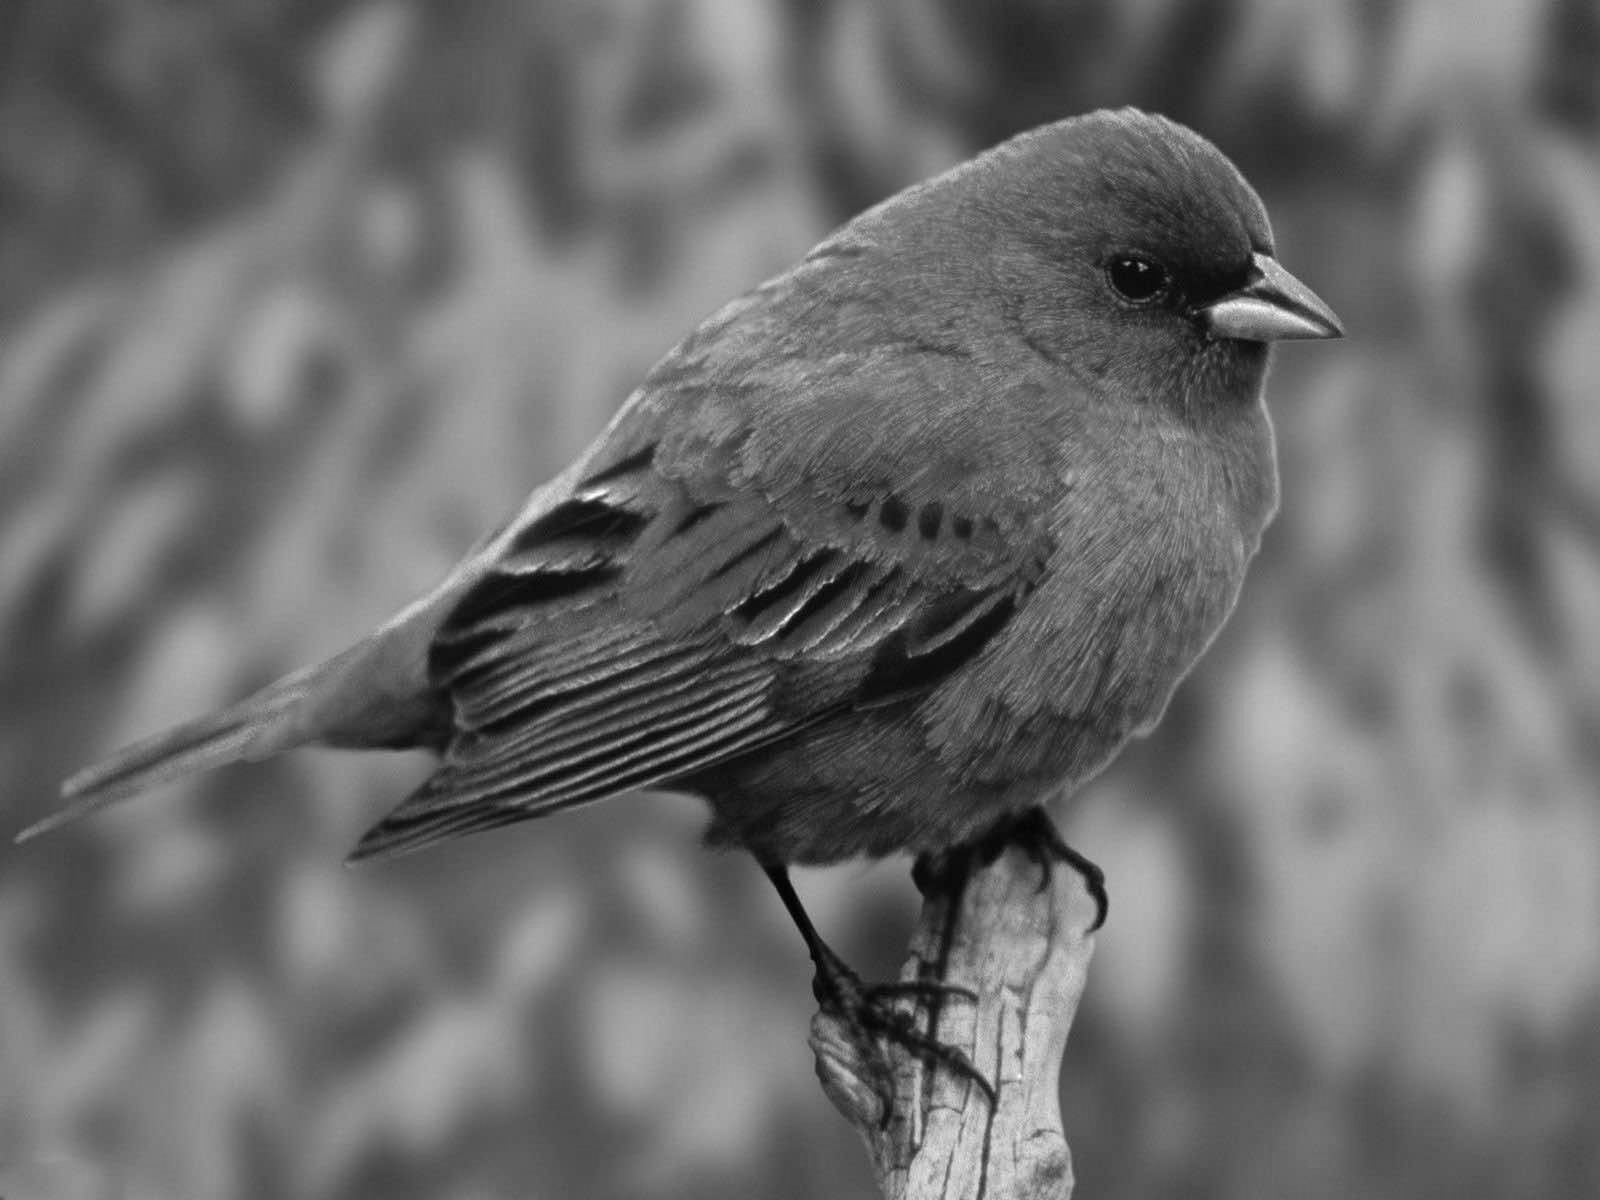

In [47]:
# Sets img to be the given image
img = Image.open("bird_image.jpg")
# Converts the image to a NumPy array of float values
rgb = np.array(img).astype(float)

# Sets weights to be NumPy array of coefficients for converting RGB to grayscale
weights = np.array([0.299, 0.587, 0.114])
# Performs a dot product between the RGB values and the weights to convert the image to grayscale
gray = rgb.dot(weights)

# Creates a grayscale image from the NumPy array of converted integer values
gray_img = Image.fromarray(gray.astype(np.uint8))

# Displays the grayscale image
display(gray_img)

# Gaussian Blur

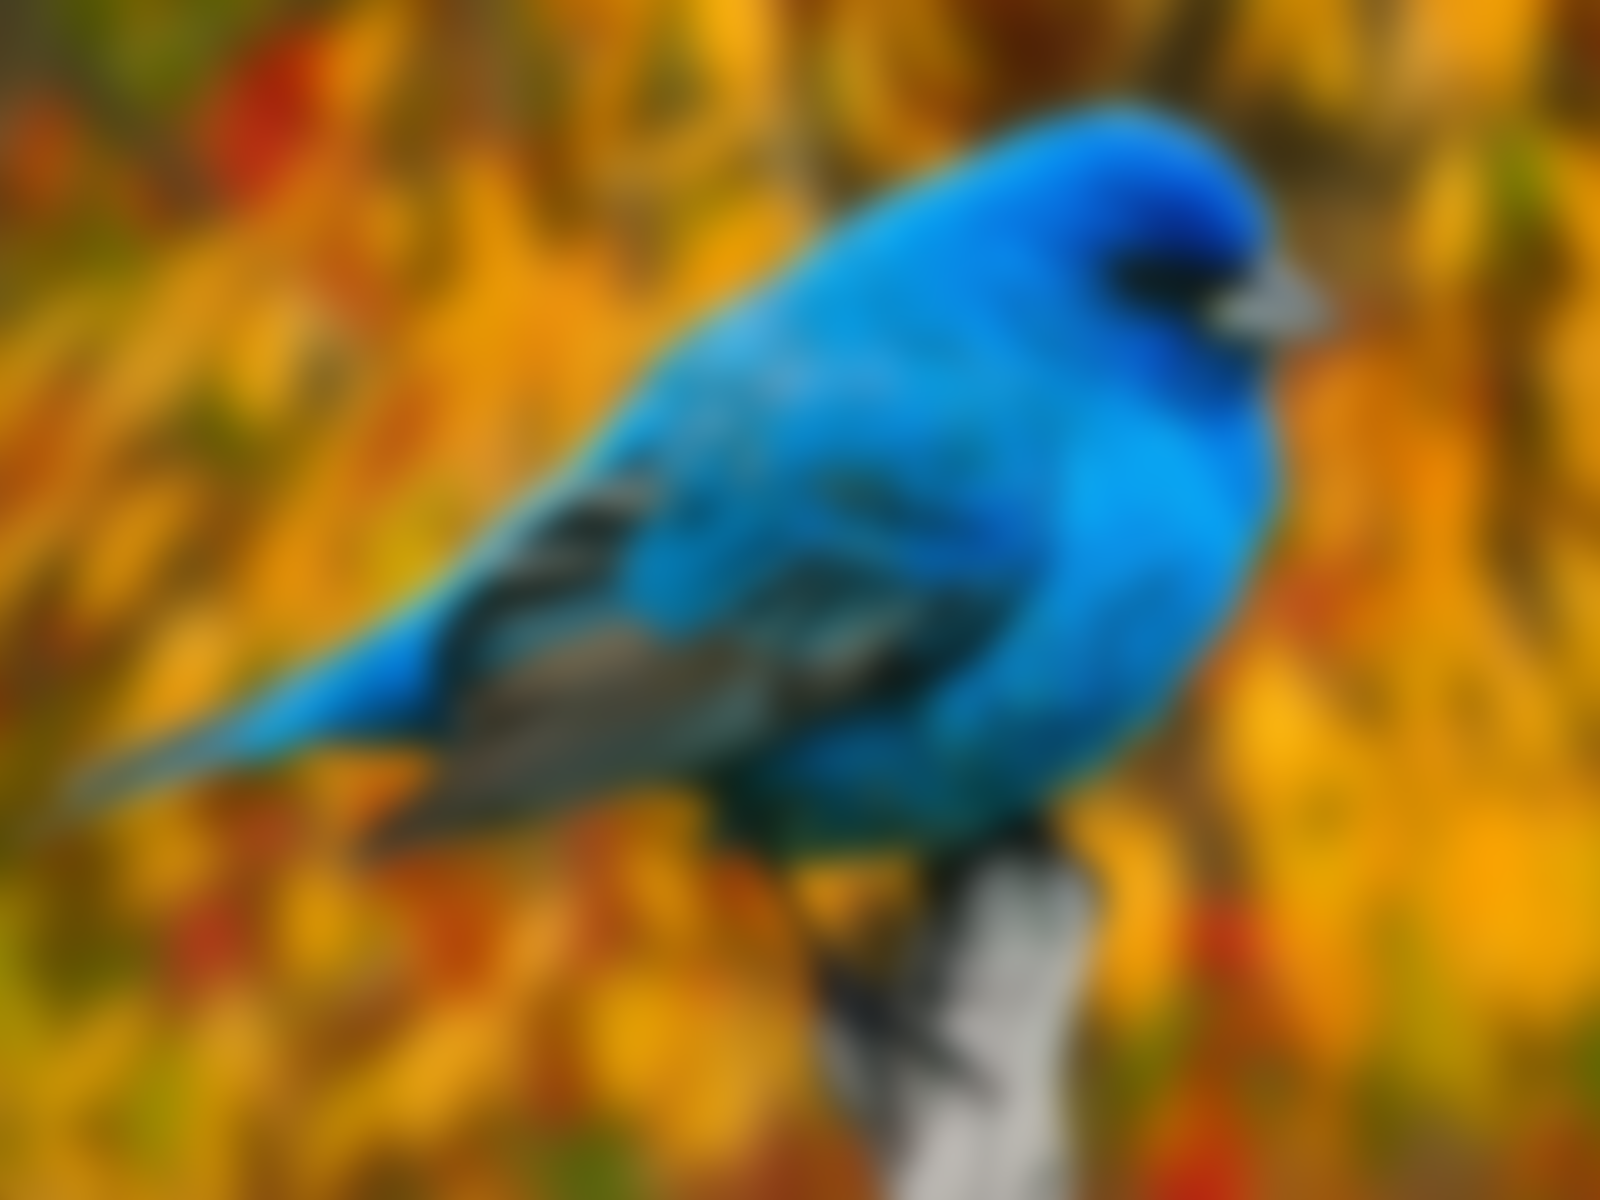

In [48]:
# Function to create a Gaussian kernel given the size and standard deviation (sigma)
def gaussian_kernel(size, sigma):
    # Creates a 1D array of evenly spaced values from -size/2 to size/2
    ax = np.linspace(-(size // 2), size // 2, size)
    # Creates a 2D grid of coordinates using meshgrid for the Gaussian function
    xx, yy = np.meshgrid(ax, ax)
    
    # Creates the kernel by passing each value through the Gaussian function
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    # Normalizes the kernel so that the sum of all its elements equals 1
    kernel = kernel / np.sum(kernel)
    # Returns the normalized Gaussian kernel
    return kernel

# Function to perform convolution of an image with a given kernel
def convolve(image, kernel):
    # Gets the height and width of the image
    img_h, img_w = image.shape
    # Gets the size of the kernel
    k = kernel.shape[0]
    # Calculates the padding size needed for the convolution operation
    pad = k // 2
    
    # Pads the image with edge values to handle borders during convolution
    padded = np.pad(image, pad, mode='edge')
    
    # Initializes an output array of zeros with the same shape as the input image to hold the convolved result
    output = np.zeros_like(image, dtype=float)
    
    # Loops through each pixel in the image and applies the convolution operation using the kernel
    for i in range(img_h):
        for j in range(img_w):
            # Extracts the region of the padded image that corresponds to the current pixel and the size of the kernel
            region = padded[i:i+k, j:j+k]
            # Computes the sum of the element-wise multiplication of the region and the kernel, and assigns it to the output pixel
            output[i, j] = np.sum(region * kernel)
    # Returns the convolved image with the Gaussian blur applied
    return output

# Function to apply Gaussian blur to an image
def gaussian_blur_manual(img_path, kernel_size, sigma):
    # Opens the image from the given path and converts it to RGB format
    img = Image.open(img_path).convert("RGB")
    # Converts the image to a NumPy array of float values
    img_np = np.array(img, dtype=float)

    # Creates the Gaussian kernel using the specified kernel size and sigma
    kernel = gaussian_kernel(kernel_size, sigma)
    
    # Initializes an array of zeros with the same shape as the input image to hold the blurred result
    blurred = np.zeros_like(img_np)
    
    # Applies convolution to each color channel (R, G, B) of the image using the Gaussian kernel
    for c in range(3):
        blurred[:, :, c] = convolve(img_np[:, :, c], kernel)

    # Clips the pixel values to be in the range [0, 255] and converts them to unsigned 8-bit integers
    blurred = np.clip(blurred, 0, 255).astype(np.uint8)
    # Creates and returns a PIL Image from the blurred NumPy array
    return Image.fromarray(blurred)

# Calls the gaussian blur function with the specified image path, kernel size, and sigma value
blurred_img = gaussian_blur_manual("bird_image.jpg", kernel_size=101, sigma=17)
# Displays the blurred image
display(blurred_img)